# Emotion (Happy or Sad) detection by Deep Learning

In [10]:
import tensorflow as tf
import os

In [11]:
import numpy as np

# Remove Dodgy images

In [12]:
data_dir='happy-sad'

In [13]:
os.listdir(data_dir)

['happy', 'happy_image_test.png', 'sad', 'sad_image_test.jpg']

In [14]:
image_exts=['jpeg','jpg','bmp','png']

In [15]:
image_exts

['jpeg', 'jpg', 'bmp', 'png']

In [16]:
image_exts[3]

'png'

In [17]:
import cv2
import imghdr
import matplotlib.pyplot as plt

In [19]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        print(image)

-smiling-positivity-confidence-isolated-blue-background-studio_590464-164648.jpg
0-truly-happy-people.jpg
05-12-21-happy-people.jpg
1000_F_86472638_HkYURYBZOogP5UuOUbIAEH84Dh5rlM2s.jpg
114QUyfpbMJdeNVGNrfhezA.jpeg
116-1168650_picture-of-a-group-of-happy-people-hugging.png
1343752991-karl-marx-surround-yourself-happy-people-2s7t.jpg
1TmthHaGINjXyFkmwsT2vZA.jpeg
1_zmI1GOBAhwyEj-Hg61hoA.jpeg
227-2271651_picture-of-a-group-of-happy-people-hugging.png
2983960_stock-photo-happy-people.jpg
35438_hd.jpg
360_F_313450534_bHkt5SoetREYpgWO5uOpceVnaDCngOX7.jpg
360_F_484873483_hg1ofIdXbMha5lKEDG3hJBrwKh1oikTq.jpg
4-things-happy-people-dont-do-cover.png
4239f3d51d092f69d529f372a37b4601.jpg
43917-Zig-Ziglar-Quote-Until-you-are-happy-with-who-you-are-you-will.jpg
450943375.jpg
45782-Tom-Bodett-Quote-They-say-a-person-needs-just-three-things-to-be.jpg
465451485.jpg
6ae25b16385ff2b80ed40ee53740dc3a.jpg
7-principles-of-successful-and-happy-people.png
7387706-Zoe-Sugg-Quote-How-can-you-be-truly-happy-with-

In [20]:
# Loads the image '154006829.jpg' from the 'happy' folder inside 'happy-sad' into memory using OpenCV
img= cv2.imread(os.path.join('happy-sad', 'happy', 'wp3720070.jpg'))

(3239, 4880, 3)


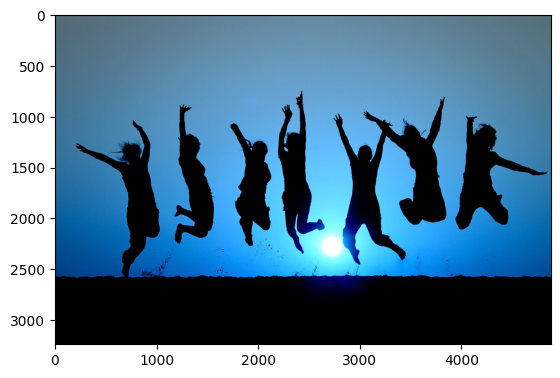

In [21]:
print(img.shape)
plt.imshow(img)

In [22]:
# Remove the image except these types: ['jpeg', 'jpg', 'bmp', 'png']

In [23]:
for image_class in os.listdir(data_dir):
    class_path = os.path.join(data_dir, image_class)   # path to "happy" or "sad"
    for image in os.listdir(class_path):               # list files inside that folder
        image_path = os.path.join(class_path, image)   # full path to each image
        try:
            img = cv2.imread(image_path)
            tip = imghdr.what(image_path)
            if tip not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))


# Load Data

In [24]:
# Loads images from the 'happy-sad' folder into a TensorFlow dataset, labeling them by subfolder name

data=tf.keras.utils.image_dataset_from_directory('happy-sad')

Found 387 files belonging to 2 classes.


In [25]:
# Converts the TensorFlow image dataset into a NumPy iterator for batch access
# Conveneient to work in numpy
data_iterator=data.as_numpy_iterator()

In [26]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x0000026FE8A73220>)

In [27]:
# Retrieves the next batch of images and their numeric labels from the dataset iterator

batch=data_iterator.next()

In [28]:
len(batch)

2

In [29]:
batch[0].shape

(32, 256, 256, 3)

In [30]:
batch[1]

array([1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0], dtype=int32)

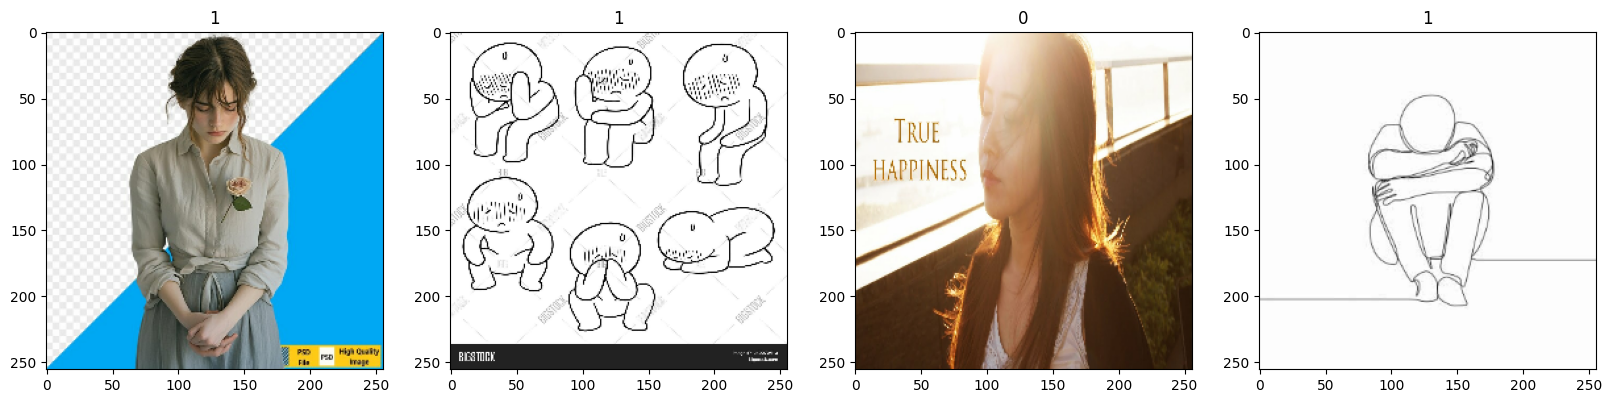

In [31]:
fig, ax= plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [32]:
# Class 1: Sad ; Class 0: Happy

# Preprocess Data

In [33]:
# Scale Data into (0-1)
# Used a map function to automatically devide all images by 255
data=data.map(lambda x,y: (x/255, y))

In [34]:
# Checking the max or min scalled value (max=1, min=0)
data.as_numpy_iterator().next()[0].max()

np.float32(1.0)

In [35]:
scaled_iterator=data.as_numpy_iterator()

# fetches the next batch from that iterator.
scaled_iterator.next()

(array([[[[1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          [1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          [1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          ...,
          [3.92156886e-03, 9.01960805e-02, 1.45098045e-01],
          [3.92156886e-03, 9.01960805e-02, 1.45098045e-01],
          [3.92156886e-03, 9.01960805e-02, 1.45098045e-01]],
 
         [[1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          [1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          [1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          ...,
          [3.92156886e-03, 9.01960805e-02, 1.45098045e-01],
          [3.92156886e-03, 9.01960805e-02, 1.45098045e-01],
          [3.92156886e-03, 9.01960805e-02, 1.45098045e-01]],
 
         [[1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          [1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          [1.17647061e-02, 1.13725491e-01, 1.72549024e-01],
          ...,
          [3.92156886e-03, 9.01960805e-02, 1.4509

# Split Data

In [36]:
len(data)

13

In [37]:
# 70% training, 20% validation, 10% test
train_size = int(len(data)*.7)
val_size=int(len(data)*.2)+1
test_size= int(len(data)*.1)+1

In [38]:
train_size+val_size+test_size

14

In [39]:
train=data.take(train_size)
val=data.skip(train_size).take(val_size)
test=data.skip(train_size+val_size).take(test_size)

len(data) → gives the number of batches in your dataset (not the number of images). In your case, there are 13 batches.

0.7 (70%) → you want ~70% of those batches for training.

int(13 * 0.7) = 9

0.2 (20%) → you want ~20% of those batches for validation.

int(13 * 0.2) = 2, then you added +1 → 3

0.1 (10%) → you want ~10% of those batches for testing.

int(13 * 0.1) = 1, then you added +1 → 2

In [40]:
len(train)

9

# Build Deep learning model

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [44]:
model= Sequential()

In [45]:
# Adding Layers
# Conv2D(16, (3,3), 1 : 16 filters, 3x3 tensors slice, 1 strike number (step)
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())

model.add(layers.Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 1 is neuron number

C:\Users\ASUS\anaconda3\envs\dl_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [47]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

# Train

In [48]:
#While your model trains, it writes out data files into logs/.
logdir='logs'
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [49]:
hist=model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 411ms/step - accuracy: 0.4896 - loss: 0.9578 - val_accuracy: 0.5833 - val_loss: 0.6583
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 382ms/step - accuracy: 0.6354 - loss: 0.6589 - val_accuracy: 0.6562 - val_loss: 0.6250
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 410ms/step - accuracy: 0.6597 - loss: 0.6157 - val_accuracy: 0.7708 - val_loss: 0.5470
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 380ms/step - accuracy: 0.7847 - loss: 0.5309 - val_accuracy: 0.8542 - val_loss: 0.4355
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 0.8125 - loss: 0.4593 - val_accuracy: 0.8854 - val_loss: 0.3222
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 0.8715 - loss: 0.3290 - val_accuracy: 0.8750 - val_loss: 0.3011
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 402ms/step - accuracy: 0.8854 - loss: 0.3212 - val_accuracy: 0.8750 - val_loss: 0.3015
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 383ms/step - accuracy: 0.8819 - loss: 0.2854 - val_accuracy: 0.8854 - val_loss:

# Plot Performance

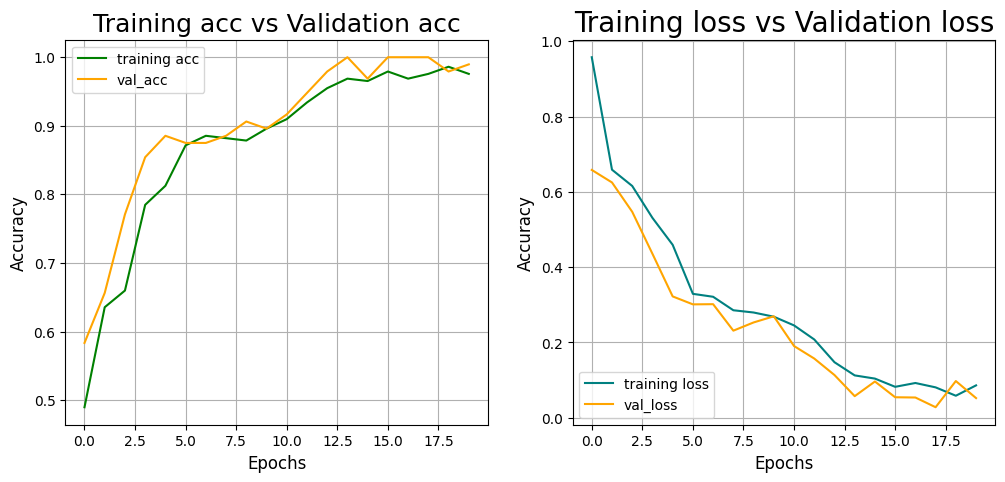

In [50]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist.history['accuracy'], color='green', label='training acc')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_acc')
plt.title('Training acc vs Validation acc', fontsize=18)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(hist.history['loss'], color='teal', label='training loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
plt.title('Training loss vs Validation loss', fontsize=20)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

# Evaluate Performance

In [51]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [52]:
pre=Precision()
re=Recall()
acc=BinaryAccuracy()

In [53]:
len(test)

1

In [54]:
for batch in test.as_numpy_iterator():
    X, y=batch
    yhat=model.predict(X)

    # Updates the metric’s running totals with the current batch of true labels and predictions
    pre.update_state(y,yhat)
    re.update_state(y,yhat)
    acc.update_state(y,yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step


In [55]:
print("Precision:", pre.result().numpy())
print("Recall:", re.result().numpy())
print("Accuracy:", acc.result().numpy())

Precision: 1.0
Recall: 1.0
Accuracy: 1.0


## Test by new image

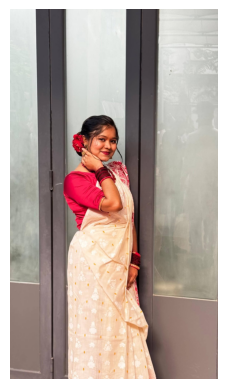

In [135]:
# Read image with OpenCV (BGR format)
img = cv2.imread('T4.jpeg')

# Convert BGR → RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize to 256x256
resize = tf.image.resize(img_rgb, (256, 256))

# Display the original image
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

In [136]:
# In this model we have to pass into a batch, as the model has been trained
print(f"Resize image shape: {resize.shape}")
print(f"Converting into a batch: {np.expand_dims(resize, 0).shape}")

Resize image shape: (256, 256, 3)
Converting into a batch: (1, 256, 256, 3)


In [137]:
# Scale to 0-1 like previous and predicting at a time
yhat=model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [138]:
yhat

array([[0.9204864]], dtype=float32)

In [139]:
from IPython.display import display, HTML

if yhat > 0.5:
    display(HTML("<span style='font-size:50px; font-weight:bold;'>Predicted class is Sad</span>"))
else:
    display(HTML("<span style='font-size:50px; font-weight:bold;'>Predicted class is Happy</span>"))
